# Imports & Reading Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
file_id = '1e5Za_BeI2r9fCZswrtQbH_t4g8naaY_k'
url = f"https://drive.google.com/uc?export=download&id={file_id}"

In [ ]:
df = pd.read_csv(url)
df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


# EDA & Cleaning

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2900 non-null   float64
 1   Stage_fear                 2900 non-null   object 
 2   Social_event_attendance    2900 non-null   float64
 3   Going_outside              2900 non-null   float64
 4   Drained_after_socializing  2900 non-null   object 
 5   Friends_circle_size        2900 non-null   float64
 6   Post_frequency             2900 non-null   float64
 7   Personality                2900 non-null   object 
dtypes: float64(5), object(3)
memory usage: 181.4+ KB


In [ ]:
df.describe()

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
count,2900.000000,2900.000000,2900.000000,2900.000000,2900.000000
mean,4.505816,3.963354,3.000000,6.268863,3.564727
std,3.441180,2.872608,2.221597,4.232340,2.893587
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,1.000000,3.000000,1.000000
50%,4.000000,3.963354,3.000000,5.000000,3.000000
75%,7.000000,6.000000,5.000000,10.000000,6.000000
max,11.000000,10.000000,7.000000,15.000000,10.000000


In [ ]:
df.describe(include='object')

,Stage_fear,Drained_after_socializing,Personality
count,2900,2900,2900
unique,2,2,2
top,No,No,Extrovert
freq,1490,1493,1491


In [ ]:
nums = df.select_dtypes('number').columns.tolist()
nums

['Time_spent_Alone',
 'Social_event_attendance',
 'Going_outside',
 'Friends_circle_size',
 'Post_frequency']

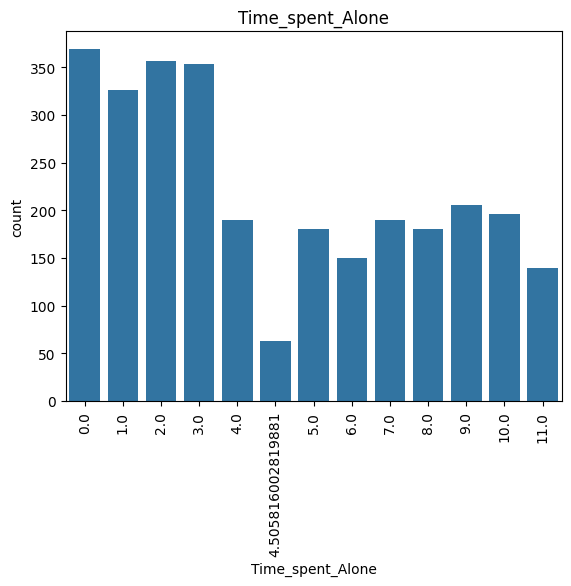

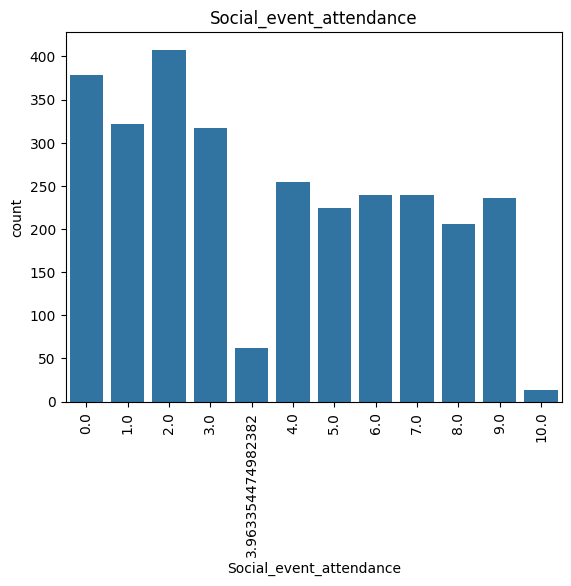

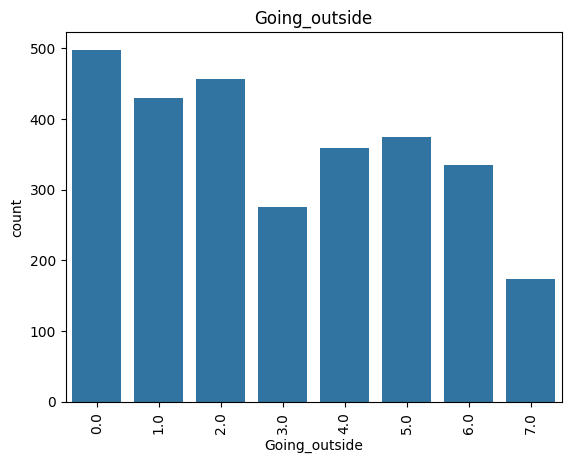

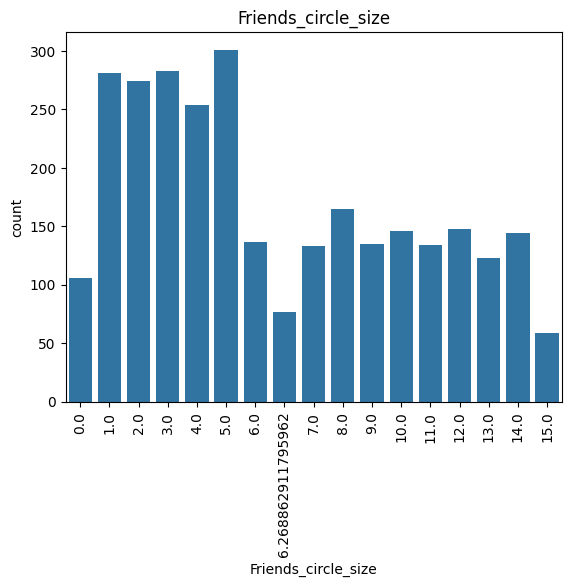

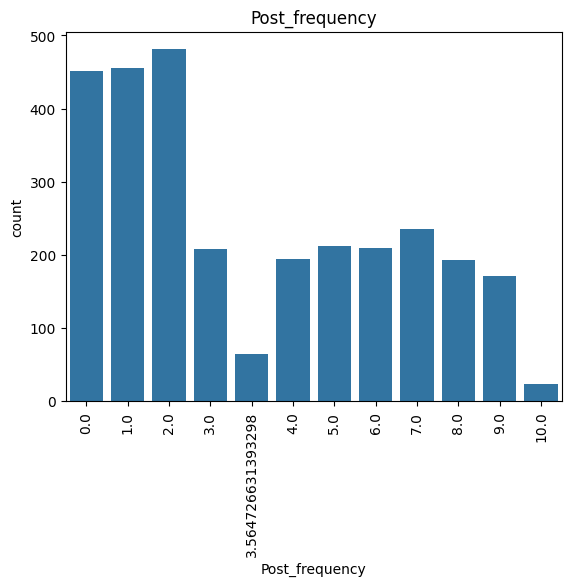

In [ ]:
for col in nums:
    plt.figure()
    sns.countplot(x=df[col])
    plt.title(col)
    plt.xticks(rotation=90)
    plt.show()

In [ ]:
df[nums] = df[nums].round()

In [ ]:
df['Post_frequency'].unique()

array([ 5.,  3.,  2.,  8.,  6.,  7.,  0., 10.,  4.,  1.,  9.])

In [ ]:
cats = df.select_dtypes('object').columns.tolist()
cats

['Stage_fear', 'Drained_after_socializing', 'Personality']

In [ ]:
for col in cats:
  print(df[col].unique())

['No' 'Yes']
['No' 'Yes']
['Extrovert' 'Introvert']


In [ ]:
df.isnull().sum()

,0
Time_spent_Alone,0
Stage_fear,0
Social_event_attendance,0
Going_outside,0
Drained_after_socializing,0
Friends_circle_size,0
Post_frequency,0
Personality,0


# Preprocessing

In [ ]:
cats = cats[:-1]
cats

['Stage_fear', 'Drained_after_socializing']

In [ ]:
df['Personality'] = df['Personality'].map({'Extrovert':1, 'Introvert':0})
df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,1
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,0
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,0
3,0.0,No,6.0,7.0,No,14.0,8.0,1
4,3.0,No,9.0,4.0,No,8.0,5.0,1


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer

yes_no_encoder = OrdinalEncoder(
    categories=[['No', 'Yes'], ['No', 'Yes']]  # order matters
)

scaler = StandardScaler()

# Modeling & Evaluation

In [ ]:
from sklearn import preprocessing
nums_pipeline = make_pipeline(scaler)
cats_pipeline = make_pipeline(yes_no_encoder)
preprocessing = ColumnTransformer([('numerical', nums_pipeline, nums), ('categorical', cats_pipeline, cats)])

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import cross_val_score

Lr_pipe = Pipeline([('preprocessing', preprocessing), ('model', LogisticRegression())])
#Lr_pipe = make_pipeline(preprocessing, LogisticRegression())
SVC_pipe = Pipeline([('preprocessing', preprocessing), ('model', SVC())])
RF_pipe = Pipeline([('preprocessing', preprocessing), ('model', RandomForestClassifier())])
DT_pipe = Pipeline([('preprocessing', preprocessing), ('model', DecisionTreeClassifier())])
AB_pipe = Pipeline([('preprocessing', preprocessing), ('model', AdaBoostClassifier())])

In [ ]:
X = df.drop('Personality', axis=1)
y = df['Personality']

In [ ]:
models = {'Logistic Regression':Lr_pipe, 'SVM':SVC_pipe,'Random Forest': RF_pipe,'Decision Tree': DT_pipe, 'Adaboost':AB_pipe}
for name, model in models.items():
  scores = cross_val_score(model, X, y, cv=10)
  print(f'{name} cv score is {np.mean(scores)} and std is {np.std(scores)}')

Logistic Regression cv score is 0.9265517241379311 and std is 0.024041680018694278
SVM cv score is 0.9344827586206895 and std is 0.02472199769508265
Random Forest cv score is 0.9199999999999999 and std is 0.017771170657551905
Decision Tree cv score is 0.8782758620689656 and std is 0.02318564892967481
Adaboost cv score is 0.9134482758620688 and std is 0.015608924548629333


In [ ]:
SVC_pipe.fit(X, y)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('standardscaler',
                                                                   StandardScaler())]),
                                                  ['Time_spent_Alone',
                                                   'Social_event_attendance',
                                                   'Going_outside',
                                                   'Friends_circle_size',
                                                   'Post_frequency']),
                                                 ('categorical',
                                                  Pipeline(steps=[('ordinalencoder',
                                                                   OrdinalEncoder(categories=[['No',
                                                                                               'Yes'],
                                                                                              ['No',
                                                                                               'Yes']]))]),
                                                  ['Stage_fear',
                                                   'Drained_after_socializing'])])),
                ('model', SVC())])

# Infrencing

In [ ]:
cols_order = ['Time_spent_Alone',	'Stage_fear',	'Social_event_attendance',	'Going_outside',	'Drained_after_socializing',	'Friends_circle_size',	'Post_frequency']
input = [4.0,	'No',	4.0,	6.0,	'No',	13.0,	5.0]

In [ ]:
input_df = pd.DataFrame([input], columns=cols_order)


In [ ]:
SVC_pipe.predict(input_df)

array([1])

In [ ]:
import pickle
with open('Pipeline.pkl', 'wb') as f:
    pickle.dump(SVC_pipe, f)